In [1]:
import openseespywin as ops
import opsvis as opsv 
import numpy as np
import ipywidgets as widgets
import os
import matplotlib.pyplot as plt
import math
import opstool as opst
#import eurocodepy as ecpy
import time as tt 
# import openseespy.postprocessing.Get_Rendering as opsplt

In [2]:
import sys
sys.path.append(r"C:\Users\micha\OneDrive\Documents\Python Scripts\open_sees\final_\functions")
import solver_function as SF
import importlib
importlib.reload(SF)
from solver_function import *  

In [3]:
opst.add_ops_hints_file()

OPSTOOL :: opensees.pyi file has been created to 
C:\Users\micha\miniconda3\envs\blue_env\Lib\site-packages\openseespywin\opensees.pyi!

In [4]:
convert_tcl = 'no'
if(convert_tcl=="yes"):
    opst.pre.tcl2py(input_file='create.tcl',
                output_file='create',
                prefix="ops")

In [ ]:
length_unit = "m"  # base unit
force_unit = "KN"  # base unit

UNIT = opst.pre.UnitSystem(length=length_unit, force=force_unit)

print("Length:", UNIT.mm, UNIT.mm2, UNIT.cm, UNIT.m,)
print("Force", UNIT.N, UNIT.kN, )
print("Stress", UNIT.MPa, UNIT.kPa, UNIT.Pa, )
print("Mass", UNIT.g, UNIT.kg, UNIT.ton)
print(UNIT)

Length: 0.001 1e-06 0.01 1
Force 0.001 1
Stress 1000.0 1.0 0.001
Mass 1e-06 0.001 1.0
<UnitSystem: length='m', force='kn', time='sec' (144628467365)>


: 

In [ ]:
ops.wipe()

# User-defined variables
massDen = 2.0
massProportionalDamping = 0.0
InitStiffnessProportionalDamping = 0.001
fangle = 31.40
ptangle = 26.50
E = 90000.0
poisson = 0.40
G = E / (2 * (1 + poisson))
B = E / (3 * (1 - 2 * poisson))
press = 0.0
deltaT = 0.010
numSteps = 1000
gamma = 0.500
period = 1
pi = math.pi
inclination = 0
unitWeightX = massDen * 9.81 * math.sin(inclination / 180.0 * pi)
unitWeightY = -massDen * 9.81 * math.cos(inclination / 180.0 * pi)
loadIncr = 1.0

# Model builder
ops.model('basic', '-ndm', 2, '-ndf', 2)

# Define material
ops.nDMaterial('PressureDependMultiYield', 2, 2, massDen, G, B, fangle, 0.1, 80, 0.5,
           ptangle, 0.17, 0.4, 10, 0, 0.015, 1.0)

# Define nodes
ops.node(1, 0.0, 0.0)
ops.node(2, 1.0, 0.0)
ops.node(3, 1.0, 1.0)
ops.node(4, 0.0, 1.0)

# Define element
ops.element('quad', 1, 1, 2, 3, 4, 1.0, 'PlaneStrain', 2, press, 0.0, unitWeightX, unitWeightY)
#ops.element('SSPquadUP', 1, 1, 2, 3, 4, 2, 1.0, 2.2e6, 1.0) #1.0e-3, 1.0e-3, 0.7, 6.0e-5, 0.0, -9.81
# Initial elastic stage
ops.updateMaterialStage('-material', 2, '-stage', 0)
ops.recorder('Node', '-file', 'fx2disp.out', '-time', '-node', *[1], '-dof', 1, 2, 3, '-dT', 0.01, 'disp')
#ops.recorder('Node', '-file', 'fx2pwp.out', '-time', '-node', *[4], '-dof', 3, '-dT', 0.01, 'Vel')
ops.recorder('Element', '-ele', 1, '-time', '-file', 'fx2stress1.out', '-dT', 0.01, 'material', 1, 'stress')
ops.recorder('Element', '-ele', 1, '-time', '-file', 'fx2strain1.out', '-dT', 0.01, 'material', 1, 'strain')

# Boundary conditions
ops.fix(1, 1, 1)
ops.fix(2, 1, 1)
ops.equalDOF(3, 4, 1, 2)

# Gravity load application
ops.numberer("RCM")
ops.system("ProfileSPD")
ops.test("NormDispIncr", 1.0e-8, 30, 0)
ops.algorithm("KrylovNewton")
ops.constraints("Penalty", 1.e18, 1.e18)
ops.integrator("Newmark", 1.5, (1.5 + 0.5) ** 2 / 4)
ops.analysis("Transient")
ops.analyze(10, 5e3)

newBulk = G * 2 / 3
# --- switch the material to plastic ---
# switch material in Python

ops.parameter(1001, 'element', 1, "bulkModulus", '2')

# Switch to plastic stage
ops.updateMaterialStage('-material', 2, '-stage', 1)
#ops.updateParameter(1001, newBulk) 

In [15]:
ops.printModel()

Current Domain Information
	Current Time: 50000
	Committed Time: 50000
NODE DATA: NumNodes: 4

numComponents: 4

 Node: 1
	Coordinates  : 0 0 
	Disps: -3.27e-18 -9.81e-18 
	Velocities   : 3.32399e-38 -2.16594e-37 
	commitAccels: 4.42652e-42 -4.66509e-41 
	 unbalanced Load: 0 0 
	ID : 6 7 


 Node: 2
	Coordinates  : 1 0 
	Disps: 3.27e-18 -9.81e-18 
	Velocities   : -3.32399e-38 -2.16594e-37 
	commitAccels: -4.42652e-42 -4.66509e-41 
	 unbalanced Load: 0 0 
	ID : 4 5 


 Node: 3
	Coordinates  : 1 1 
	Disps: 1.6269e-18 -5.08667e-05 
	Velocities   : -1.52923e-37 -2.24616e-24 
	commitAccels: -2.33808e-41 -4.83787e-28 
	 unbalanced Load: 0 0 
	ID : 2 3 


 Node: 4
	Coordinates  : 0 1 
	Disps: -1.6431e-18 -5.08667e-05 
	Velocities   : 5.79525e-38 -2.24616e-24 
	commitAccels: 1.65728e-41 -4.83787e-28 
	 unbalanced Load: 0 0 
	ID : 0 1 

ELEMENT DATA: NumEle: 1

numComponents: 1

FourNodeQuad, element id:  1
	Connected external nodes:  1 2 3 4 
	thickness:  1
	surface pressure:  0
	mass density:

In [16]:
opst.vis.plotly.plot_model(show_node_numbering=True, show_ele_numbering=False, show_nodal_loads = True)

In [17]:
# Apply pushover load

ops.setTime(0.0)
ops.wipeAnalysis()
ops.timeSeries('Linear', 1)
ops.pattern('Plain', 1, 1)
ops.load(3, loadIncr, 0.0)

# Recorders
ops.recorder('Node', '-file', 'f2disp.out', '-time', '-node', *[1, 2, 3, 4], '-dof', 1, 2, '-dT', 0.01, 'disp')
ops.recorder('Node', '-file', 'f2acce.out', '-time', '-node', *[1, 2, 3, 4], '-dof', 1, 2, '-dT', 0.01, 'accel')
ops.recorder('Element', '-ele', 1, '-time', '-file', 'f2stress1.out', '-dT', 0.01, 'material', 1, 'stress')
ops.recorder('Element', '-ele', 1, '-time', '-file', 'f2strain1.out', '-dT', 0.01, 'material', 1, 'strain')
ops.recorder('Element', '-ele', 1, '-time', '-file', 'f2stress3.out', '-dT', 0.01, 'material', 3, 'stress')
ops.recorder('Element', '-ele', 1, '-time', '-file', 'f2strain3.out', '-dT', 0.01, 'material', 3, 'strain')

# Static analysis for pushover
ops.numberer("RCM")
ops.system("ProfileSPD")
ops.test("NormDispIncr", 1.0e-8, 30, 0)
ops.algorithm("KrylovNewton")
ops.constraints("Penalty", 1.e18, 1.e18)
ops.integrator("Newmark", 1.5, (1.5 + 0.5) ** 2 / 4)
ops.analysis('VariableTransient') #VariableTransient

ODB = opst.post.CreateODB(
    odb_tag="PDMY05",
    compute_mechanical_measures=True,
    project_gauss_to_nodes="copy",  # "extrapolate", "copy", "average"
)


startT = tt.time()
for _ in range(1000):
    ops.analyze(1, deltaT, deltaT / 100, deltaT, 10)
    ODB.fetch_response_step()
ODB.save_response(zlib=True)
endT = tt.time()

ops.wipe()

OPSTOOL ::  All responses data with _odb_tag = PDMY05 saved in .opstool.output/RespStepData-PDMY05.nc!

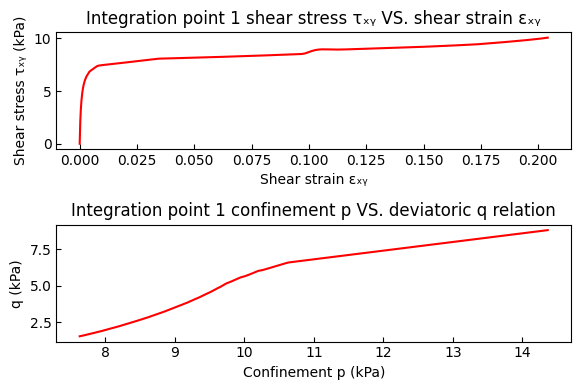

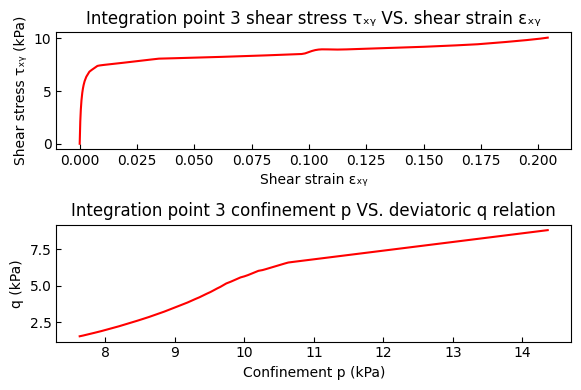

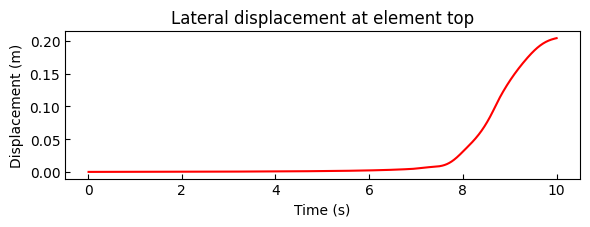

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Load data
a1 = np.loadtxt('f2acce.out')
d1 = np.loadtxt('f2disp.out')
s1 = np.loadtxt('f2stress1.out')
e1 = np.loadtxt('f2strain1.out')
s5 = np.loadtxt('f2stress3.out')
e5 = np.loadtxt('f2strain3.out')

# Approximate MATLAB paperposition as figure size
figsize = (6, 4)

def compute_p_q(stress):
    """Compute confinement p (po) and deviatoric stress q (qo)."""
    po = np.mean(stress[:, 1:4], axis=1)
    qo = []
    for i in range(len(stress)):
        q = ((stress[i,1] - stress[i,2])**2 +
             (stress[i,2] - stress[i,3])**2 +
             (stress[i,1] - stress[i,3])**2 +
             6.0 * stress[i,4]**2)
        q = np.sign(stress[i,4]) * (1/3.0) * np.sqrt(q)
        qo.append(q)
    return po, np.array(qo)

# --- Integration Point 1 ---
po1, qo1 = compute_p_q(s1)

plt.figure(1, figsize=figsize)
plt.clf()
plt.subplot(2,1,1)
plt.plot(e1[:,3], s1[:,4], 'r') #CHANGE THE DATA FRAME LOCATION OF STRAIN
plt.title('Integration point 1 shear stress τₓᵧ VS. shear strain εₓᵧ')
plt.xlabel('Shear strain εₓᵧ')
plt.ylabel('Shear stress τₓᵧ (kPa)')

plt.subplot(2,1,2)
plt.plot(-po1, qo1, 'r')
plt.title('Integration point 1 confinement p VS. deviatoric q relation')
plt.xlabel('Confinement p (kPa)')
plt.ylabel('q (kPa)')

plt.tight_layout()
plt.savefig('SS_PQ1.jpg')
plt.show()

# --- Integration Point 3 ---
po3, qo3 = compute_p_q(s5)

plt.figure(4, figsize=figsize)
plt.clf()
plt.subplot(2,1,1)
plt.plot(e5[:,3], s5[:,4], 'r')
plt.title('Integration point 3 shear stress τₓᵧ VS. shear strain εₓᵧ')
plt.xlabel('Shear strain εₓᵧ')
plt.ylabel('Shear stress τₓᵧ (kPa)')

plt.subplot(2,1,2)
plt.plot(-po3, qo3, 'r')
plt.title('Integration point 3 confinement p VS. deviatoric q relation')
plt.xlabel('Confinement p (kPa)')
plt.ylabel('q (kPa)')

plt.tight_layout()
plt.savefig('SS_PQ5.jpg')
plt.show()

# --- Displacement ---
plt.figure(2, figsize=figsize)
plt.clf()
plt.subplot(2,1,1)
plt.plot(d1[:,0], d1[:,5], 'r')  # MATLAB col 6 → Python col index 5
plt.title('Lateral displacement at element top')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')

plt.tight_layout()
plt.savefig('D.jpg')
plt.show()


In [19]:
ele_resp = opst.post.get_element_responses(odb_tag="PDMY05", ele_type="Plane")
print("Data Variables in Element Responses:", ele_resp.data_vars)

OPSTOOL ::  Loading Plane response data from .opstool.output/RespStepData-PDMY05.nc ...

Data Variables in Element Responses: Data variables:
    Stresses               (time, eleTags, GaussPoints, stressDOFs) float32 80kB ...
    Strains                (time, eleTags, GaussPoints, strainDOFs) float32 48kB ...
    StressesAtNodes        (time, nodeTags, stressDOFs) float32 80kB -6.54 .....
    StrainsAtNodes         (time, nodeTags, strainDOFs) float32 48kB 5.849e-1...
    StressAtNodesErr       (time, nodeTags, stressDOFs) float32 80kB 0.0 ... 0.0
    StrainsAtNodesErr      (time, nodeTags, strainDOFs) float32 48kB 0.0 ... 0.0
    StressMeasures         (time, eleTags, GaussPoints, measures) float32 64kB ...
    StrainMeasures         (time, eleTags, GaussPoints, measures) float32 64kB ...
    StressMeasuresAtNodes  (time, nodeTags, measures) float32 64kB -6.54 ... ...
    StrainMeasuresAtNodes  (time, nodeTags, measures) float32 64kB 0.0 ... 0....


In [20]:
ele_resp.data_vars

Data variables:
    Stresses               (time, eleTags, GaussPoints, stressDOFs) float32 80kB ...
    Strains                (time, eleTags, GaussPoints, strainDOFs) float32 48kB ...
    StressesAtNodes        (time, nodeTags, stressDOFs) float32 80kB -6.54 .....
    StrainsAtNodes         (time, nodeTags, strainDOFs) float32 48kB 5.849e-1...
    StressAtNodesErr       (time, nodeTags, stressDOFs) float32 80kB 0.0 ... 0.0
    StrainsAtNodesErr      (time, nodeTags, strainDOFs) float32 48kB 0.0 ... 0.0
    StressMeasures         (time, eleTags, GaussPoints, measures) float32 64kB ...
    StrainMeasures         (time, eleTags, GaussPoints, measures) float32 64kB ...
    StressMeasuresAtNodes  (time, nodeTags, measures) float32 64kB -6.54 ... ...
    StrainMeasuresAtNodes  (time, nodeTags, measures) float32 64kB 0.0 ... 0....

In [21]:
print(ele_resp.stressDOFs.data)
print(ele_resp.strainDOFs.data)
print(ele_resp.measures.data)

['sigma11' 'sigma22' 'sigma12' 'sigma33' 'eta_r']
['eps11' 'eps22' 'eps12']
['p1' 'p2' 'sigma_vm' 'tau_max']


In [22]:
sigma11 = ele_resp["Stresses"].sel(stressDOFs="sigma11", eleTags=1)
sigma22 = ele_resp["Stresses"].sel(stressDOFs="sigma22", eleTags=1)
sigma33 = ele_resp["Stresses"].sel(stressDOFs="sigma33", eleTags=1)
sigma12 = ele_resp["Stresses"].sel(stressDOFs="sigma12", eleTags=1)
eta_r = ele_resp["Stresses"].sel(stressDOFs="eta_r", eleTags=1)

In [23]:
s11 = sigma11.sel(GaussPoints=1)
s22 = sigma22.sel(GaussPoints=1)
s33 = sigma33.sel(GaussPoints=1)
s12 = sigma12.sel(GaussPoints=1)

In [24]:
po = (sigma11 + sigma22 + sigma33) / 3.0
qo = (sigma11 - sigma22) ** 2 + (sigma22 - sigma33) ** 2 + (sigma33 - sigma11) ** 2 + 6 * (sigma12**2)
qo = np.sign(sigma12) * 1 / 3 * np.sqrt(qo)
print(qo)

<xarray.DataArray 'Stresses' (time: 1001, GaussPoints: 4)> Size: 16kB
array([[ 1.5414929, -1.5414929, -1.5414929,  1.5414929],
       [ 1.541497 ,  1.541497 ,  1.541497 ,  1.541497 ],
       [ 1.5415219,  1.5415219,  1.5415219,  1.5415219],
       ...,
       [ 8.809625 ,  8.809625 ,  8.809625 ,  8.809625 ],
       [ 8.816222 ,  8.816222 ,  8.816222 ,  8.816222 ],
       [ 8.822691 ,  8.822691 ,  8.822691 ,  8.822691 ]],
      shape=(1001, 4), dtype=float32)
Coordinates:
  * time         (time) float32 4kB 0.0 0.01 0.02 0.03 ... 9.97 9.98 9.99 10.0
    eleTags      int64 8B 1
  * GaussPoints  (GaussPoints) int64 32B 1 2 3 4
    stressDOFs   <U7 28B 'sigma12'


In [25]:
eps11 = ele_resp["Strains"].sel(strainDOFs="eps11", eleTags=1)
eps22 = ele_resp["Strains"].sel(strainDOFs="eps22", eleTags=1)
eps12 = ele_resp["Strains"].sel(strainDOFs="eps12", eleTags=1)

In [26]:
ep11 = eps11.sel(GaussPoints=1)
ep22 = eps22.sel(GaussPoints=1)
ep12 = eps12.sel(GaussPoints=1)
print(ep11)

<xarray.DataArray 'Strains' (time: 1001)> Size: 4kB
array([5.8489676e-18, 5.8500198e-18, 5.8510389e-18, ..., 6.9388939e-18,
       0.0000000e+00, 1.3877788e-17], shape=(1001,), dtype=float32)
Coordinates:
  * time         (time) float32 4kB 0.0 0.01 0.02 0.03 ... 9.97 9.98 9.99 10.0
    eleTags      int64 8B 1
    GaussPoints  int64 8B 1
    strainDOFs   <U5 20B 'eps11'


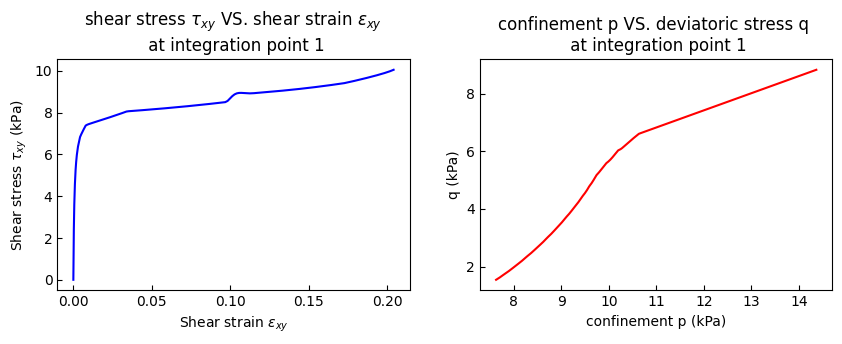

In [27]:
eps12_ele1_1 = eps12.sel(GaussPoints=1).values
sigma12_ele1_1 = sigma12.sel(GaussPoints=1).values
po_ele1_1 = po.sel(GaussPoints=1)
qo_ele1_1 = qo.sel(GaussPoints=1)

fig, axs = plt.subplots(1, 2, figsize=(10, 3))
axs[0].plot(eps12_ele1_1, sigma12_ele1_1, "b")
axs[0].set_title("shear stress $\\tau_{xy}$ VS. shear strain $\\epsilon_{xy}$ \n at integration point 1")
axs[0].set_xlabel(r"Shear strain $\epsilon_{xy}$")
axs[0].set_ylabel(r"Shear stress $\tau_{xy}$ (kPa)")
axs[1].plot(-po_ele1_1, qo_ele1_1, "r")
axs[1].set_title("confinement p VS. deviatoric stress q \n at integration point 1")
axs[1].set_xlabel("confinement p (kPa)")
axs[1].set_ylabel("q (kPa)")
plt.show()

In [28]:
node_resp = opst.post.get_nodal_responses(odb_tag="PDMY05")
print(node_resp)

OPSTOOL ::  Loading all response data from .opstool.output/RespStepData-PDMY05.nc ...

<xarray.Dataset> Size: 597kB
Dimensions:             (time: 1001, nodeTags: 4, DOFs: 6)
Coordinates:
  * time                (time) float32 4kB 0.0 0.01 0.02 0.03 ... 9.98 9.99 10.0
  * nodeTags            (nodeTags) int64 32B 1 2 3 4
  * DOFs                (DOFs) <U2 48B 'UX' 'UY' 'UZ' 'RX' 'RY' 'RZ'
Data variables:
    disp                (time, nodeTags, DOFs) float32 96kB -3.27e-18 ... 0.0
    vel                 (time, nodeTags, DOFs) float32 96kB 3.324e-38 ... 0.0
    accel               (time, nodeTags, DOFs) float32 96kB 4.427e-42 ... 0.0
    reaction            (time, nodeTags, DOFs) float32 96kB 3.27 9.81 ... 0.0
    reactionIncInertia  (time, nodeTags, DOFs) float32 96kB 3.27 9.81 ... 0.0
    rayleighForces      (time, nodeTags, DOFs) float32 96kB 0.0 0.0 ... 0.0 0.0
    pressure            (time, nodeTags) float32 16kB 0.0 0.0 0.0 ... 0.0 0.0
Attributes:
    UX:       Displacement in X direction
    UY:       Displacement in Y direction
    UZ:       Displacement in Z dire

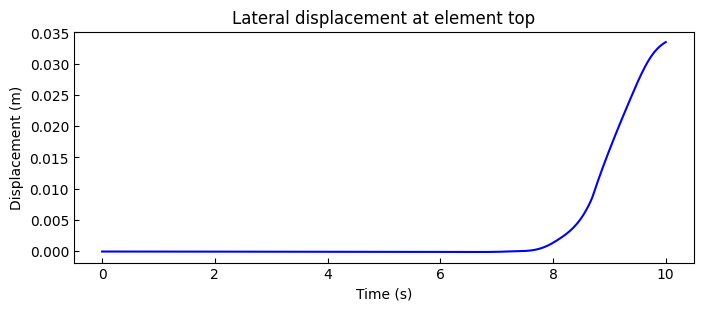

[-5.0866667e-05 -5.0866871e-05 -5.0867664e-05 ...  3.3340190e-02
  3.3396948e-02  3.3451952e-02]


In [29]:
disp1 = node_resp["disp"].sel(nodeTags=1, DOFs="UY")
disp3 = node_resp["disp"].sel(nodeTags=3, DOFs="UY")
times = node_resp["time"].data

fig, ax = plt.subplots(1, 1, figsize=(8, 3))
ax.plot(times, disp3 - disp1, "b")
ax.set_title("Lateral displacement at element top")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Displacement (m)")
plt.show()
print(disp3.values)

In [30]:
from scipy.interpolate import interp1d


t = np.linspace(0, 20 * np.pi, int(20 * np.pi / (np.pi / 50)) + 1)
s = 2 * np.sin(t)
s = np.concatenate((s, np.zeros(3000)))
x_original = np.linspace(0, 40, len(s))
interp_func = interp1d(x_original, s, kind="linear", fill_value="extrapolate")
s1 = interp_func(times)

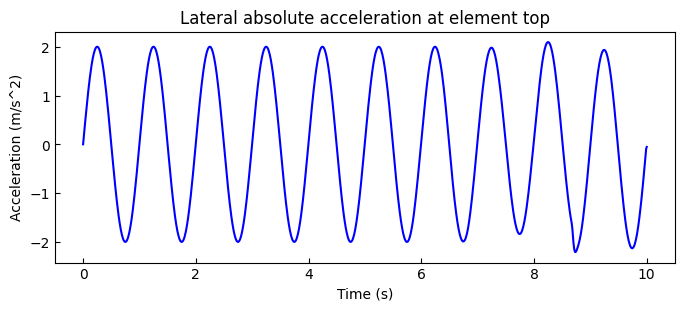

In [31]:
acc3 = node_resp["accel"].sel(nodeTags=3, DOFs="UX")
times = node_resp["time"].data

fig, ax = plt.subplots(1, 1, figsize=(8, 3))
ax.plot(times, s1 + acc3, "b")
ax.set_title("Lateral absolute acceleration at element top")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Acceleration (m/s^2)")
plt.show()

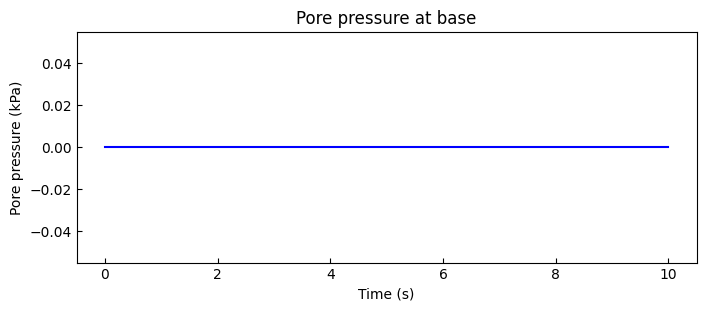

In [32]:
p1 = node_resp["vel"].sel(nodeTags=1, DOFs="RZ")

fig, ax = plt.subplots(1, 1, figsize=(8, 3))

ax.plot(times, p1, "b")
ax.set_title("Pore pressure at base")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Pore pressure (kPa)")
plt.show()

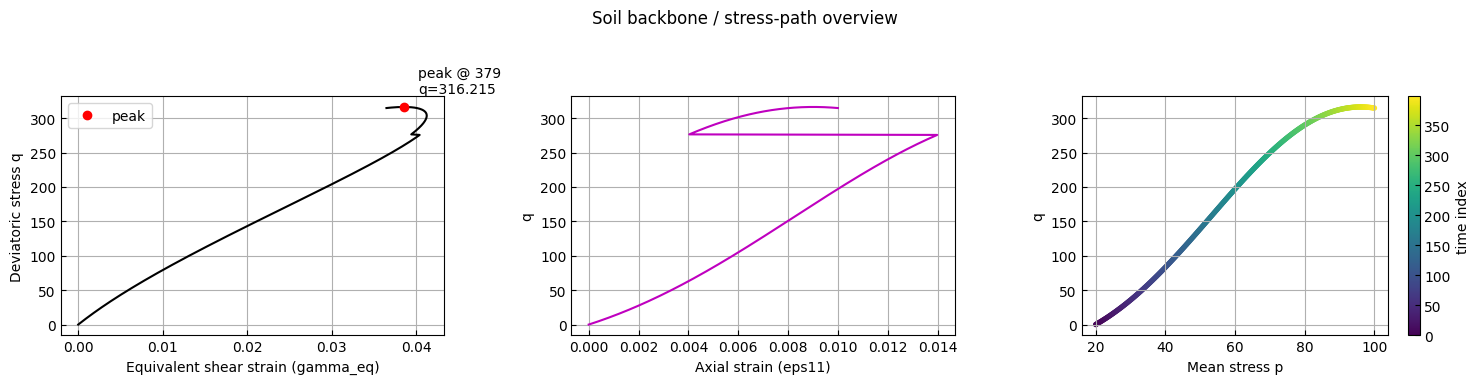

Detection summary: {'peak_index': 379, 'peak_q': 316.2145347571352, 'peak_gamma': 0.03855993569519752, 'failure_index': None, 'failure_q': None, 'failure_gamma': None, 'p': array([ 20.        ,  20.20050125,  20.40100251,  20.60150376,
        20.80200501,  21.00250627,  21.20300752,  21.40350877,
        21.60401003,  21.80451128,  22.00501253,  22.20551378,
        22.40601504,  22.60651629,  22.80701754,  23.0075188 ,
        23.20802005,  23.4085213 ,  23.60902256,  23.80952381,
        24.01002506,  24.21052632,  24.41102757,  24.61152882,
        24.81203008,  25.01253133,  25.21303258,  25.41353383,
        25.61403509,  25.81453634,  26.01503759,  26.21553885,
        26.4160401 ,  26.61654135,  26.81704261,  27.01754386,
        27.21804511,  27.41854637,  27.61904762,  27.81954887,
        28.02005013,  28.22055138,  28.42105263,  28.62155388,
        28.82205514,  29.02255639,  29.22305764,  29.4235589 ,
        29.62406015,  29.8245614 ,  30.02506266,  30.22556391,
        

In [33]:
"""
File: scripts/soil_backbone_plot.py

PSEUDOCODE / PLAN
1. Read stress and strain time-series arrays: sigma11, sigma22, sigma33, sigma12 (shear), eps11, eps22, eps33, eps12.
   - Support either separate 1D arrays or an Nx6 array in Voigt order [s11,s22,s33,s12,s23,s13] and strains similarly.
2. Compute mean stress p = (s11+s22+s33)/3 at each step.
3. Compute deviatoric stress tensor s_ij = sigma_ij - p*I.
4. Compute q (deviatoric stress magnitude) using q = sqrt(3/2 * s_ij : s_ij).
5. Compute volumetric strain eps_v = eps11+eps22+eps33.
6. Compute deviatoric strain tensor e_dev = eps_ij - eps_v/3 * I.
7. Compute equivalent shear strain (norm) gamma_eq = sqrt(2/3 * e_dev : e_dev).
8. Produce plots:
   a. q vs gamma_eq (backbone curve) with markers for peak q (failure).
   b. q vs axial strain (eps11) optionally.
   c. p-q plot (stress path), color by time/index.
9. Identify failure point heuristics:
   - peak q (maximum deviatoric stress)
   - post-peak drop (e.g., 10% drop from peak) or when q decreases for N consecutive steps.
   - large increase in gamma_eq at small q (softening) — report index and strain.
10. Export figure. Provide CLI-style example and helper to load CSV files.

Features implemented in code below:
- Robust handling of input shapes
- Functions: compute_p_q, compute_gamma_eq, detect_peak_failure
- Example synthetic dataset generator
- Matplotlib plots with annotated failure point

"""

import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Dict, Optional

# --- Core computations -----------------------------------------------------

def compute_p_q(s11: np.ndarray, s22: np.ndarray, s33: np.ndarray, s12: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """Compute mean stress p and deviatoric stress magnitude q for plane-stress/shear input.
    Assumes all inputs have same 1D length.
    Uses full 3D invariants assuming shear components s23=s13=0.
    Returns (p, q) arrays.
    """
    s11 = np.asarray(s11)
    s22 = np.asarray(s22)
    s33 = np.asarray(s33)
    s12 = np.asarray(s12)

    p = (s11 + s22 + s33) / 3.0

    # deviatoric components
    s1 = s11 - p
    s2 = s22 - p
    s3 = s33 - p
    # shear components in tensor form: engineering shear stored as s12
    s12_comp = s12
    s21_comp = s12_comp  # symmetric

    # compute s_ij : s_ij = s11^2 + s22^2 + s33^2 + 2*(s12^2 + s23^2 + s13^2)
    # assume s23=s13=0 for provided data; if available extend inputs
    s_dot_s = s1**2 + s2**2 + s3**2 + 2.0 * (s12_comp**2)

    q = np.sqrt(1.5 * s_dot_s)
    return p, q


def compute_gamma_eq(e11: np.ndarray, e22: np.ndarray, e33: np.ndarray, e12: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """Compute volumetric strain and equivalent shear (deviatoric) strain gamma_eq.
    gamma_eq = sqrt(2/3 * e_dev : e_dev)
    Returns (eps_vol, gamma_eq)
    """
    e11 = np.asarray(e11)
    e22 = np.asarray(e22)
    e33 = np.asarray(e33)
    e12 = np.asarray(e12)

    eps_v = e11 + e22 + e33
    # deviatoric strains
    ed1 = e11 - eps_v / 3.0
    ed2 = e22 - eps_v / 3.0
    ed3 = e33 - eps_v / 3.0
    ed12 = e12

    ed_dot_ed = ed1**2 + ed2**2 + ed3**2 + 2.0 * (ed12**2)
    gamma_eq = np.sqrt(2.0/3.0 * ed_dot_ed)
    return eps_v, gamma_eq


def detect_peak_failure(q: np.ndarray, gamma: np.ndarray, drop_frac: float = 0.1, lookahead: int = 3) -> Dict:
    """Detect peak deviatoric stress and simple failure heuristic.
    Returns dict with peak_index, peak_q, failure_index (first index where q < (1-drop_frac)*peak after peak
    and stays below for `lookahead` steps), and corresponding gamma.
    """
    q = np.asarray(q)
    peak_idx = int(np.argmax(q))
    peak_q = q[peak_idx]

    # find first sustained drop below threshold
    thresh = (1.0 - drop_frac) * peak_q
    failure_idx: Optional[int] = None
    for i in range(peak_idx + 1, len(q) - lookahead):
        if np.all(q[i:i+lookahead] < thresh):
            failure_idx = i
            break

    result = {
        'peak_index': peak_idx,
        'peak_q': float(peak_q),
        'peak_gamma': float(gamma[peak_idx]) if len(gamma)>peak_idx else None,
        'failure_index': int(failure_idx) if failure_idx is not None else None,
        'failure_q': float(q[failure_idx]) if failure_idx is not None else None,
        'failure_gamma': float(gamma[failure_idx]) if (failure_idx is not None and len(gamma)>failure_idx) else None
    }
    return result

# --- Plotting helpers -----------------------------------------------------

def plot_backbone(q: np.ndarray, gamma: np.ndarray, eps_axial: Optional[np.ndarray] = None, p: Optional[np.ndarray] = None, meta: Dict = None, outname: Optional[str] = None) -> None:
    """Create a 3-panel figure:
      1) q vs gamma (backbone) with peak/failure markers
      2) q vs axial strain (if provided)
      3) p-q stress path (if p provided)

    Saves to outname if given, otherwise shows interactively.
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Panel 1: backbone
    axes[0].plot(gamma, q, '-k', lw=1.5)
    axes[0].set_xlabel('Equivalent shear strain (gamma_eq)')
    axes[0].set_ylabel('Deviatoric stress q')
    axes[0].grid(True)

    # annotate peak and failure if meta provided
    if meta is not None:
        peak = meta.get('peak_index')
        failure = meta.get('failure_index')
        if peak is not None:
            axes[0].plot(gamma[peak], q[peak], 'ro', label='peak')
            axes[0].annotate(f'peak @ {peak}\nq={q[peak]:.3f}', xy=(gamma[peak], q[peak]), xytext=(10,10), textcoords='offset points')
        if failure is not None:
            axes[0].plot(gamma[failure], q[failure], 'bx', label='failure')
            axes[0].annotate(f'failure @ {failure}\nq={q[failure]:.3f}', xy=(gamma[failure], q[failure]), xytext=(-60,-20), textcoords='offset points')
    axes[0].legend()

    # Panel 2: q vs axial strain
    if eps_axial is not None:
        axes[1].plot(eps_axial, q, '-m')
        axes[1].set_xlabel('Axial strain (eps11)')
        axes[1].set_ylabel('q')
        axes[1].grid(True)
    else:
        axes[1].axis('off')

    # Panel 3: p-q path
    if p is not None:
        sc = axes[2].scatter(p, q, c=np.arange(len(q)), cmap='viridis', s=8)
        axes[2].set_xlabel('Mean stress p')
        axes[2].set_ylabel('q')
        axes[2].grid(True)
        fig.colorbar(sc, ax=axes[2], label='time index')
    else:
        axes[2].axis('off')

    fig.suptitle('Soil backbone / stress-path overview')
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])

    if outname:
        fig.savefig(outname, dpi=300)
        print(f"Saved figure to {outname}")
    else:
        plt.show()

# --- CLI-like wrapper -----------------------------------------------------

def analyze_and_plot(stress: Dict[str, np.ndarray], strain: Dict[str, np.ndarray], outname: Optional[str] = None) -> Dict:
    """stress: dict with keys s11,s22,s33,s12
    strain: dict with keys e11,e22,e33,e12
    Returns metadata including indices of peak and failure.
    """
    p, q = compute_p_q(stress['s11'], stress['s22'], stress['s33'], stress['s12'])
    eps_v, gamma = compute_gamma_eq(strain['e11'], strain['e22'], strain['e33'], strain['e12'])

    meta = detect_peak_failure(q, gamma, drop_frac=0.10, lookahead=5)

    plot_backbone(q, gamma, eps_axial=strain.get('e11'), p=p, meta=meta, outname=outname)
    return {**meta, 'p': p, 'q': q, 'gamma': gamma}

# --- Example usage / synthetic data for quick test ------------------------
if __name__ == '__main__':
    # synthetic triaxial-like loading: monotonic loading to peak then softening
    n = 400
    t = np.linspace(0, 1, n)
    # create a rising q then drop
    q_synthetic = 400.0 * t * np.exp(-1.5 * (t - 0.6)**2)
    # create synthetic stresses consistent with q and p (for demo only)
    p_syn = 100.0 * (0.2 + 0.8 * t)

    # reverse engineer deviatoric components (simple axisymmetric assumption)
    # set s2 = s3 for axial loading: s11 = s_axial, s22=s33 = confining
    # solve for s11,s22,s33 such that p and q approximately match
    s11 = p_syn + 2.0/3.0 * q_synthetic
    s22 = p_syn - 1.0/3.0 * q_synthetic
    s33 = s22
    s12 = np.zeros_like(t)

    # synthetic strains: small volumetric compaction then shear
    e11 = 0.02 * t - 0.01 * (t>0.7)
    e22 = -0.001 * t
    e33 = -0.001 * t
    e12 = 0.05 * t * np.exp(-3*(t-0.6)**2)

    stress = {'s11': s11, 's22': s22, 's33': s33, 's12': s12}
    strain = {'e11': e11, 'e22': e22, 'e33': e33, 'e12': e12}

    meta = analyze_and_plot(stress, strain, outname=None)
    print('Detection summary:', meta)


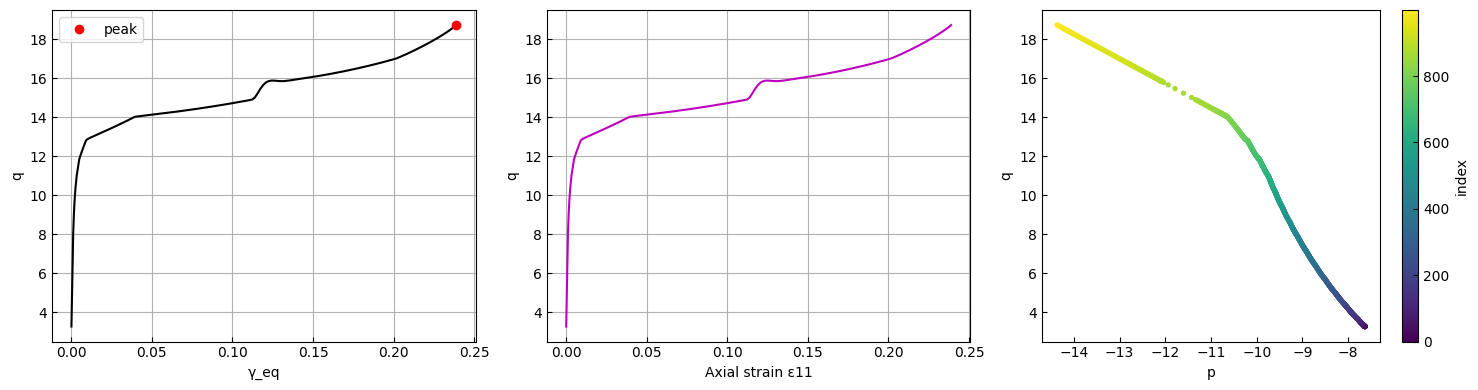

In [34]:
"""
File: scripts/soil_backbone_plot.py

Now supports reading your .out stress and strain files (time + stress/strain values).
"""

import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Dict, Optional

def load_stress_file(filename: str):
    data = np.loadtxt(filename)
    time = data[:, 0]
    s11 = data[:, 1]
    s22 = data[:, 2]
    s33 = data[:, 3]
    s12 = data[:, 4]
    return time, s11, s22, s33, s12

def load_strain_file(filename: str):
    data = np.loadtxt(filename)
    time = data[:, 0]
    e11 = data[:, 1]
    e22 = data[:, 2]
    e12 = data[:, 3]
    return time, e11, e22, e12

def trim_to_same_length(*arrays):
    arrays_np = [np.asarray(a) for a in arrays]
    min_len = min(len(a) for a in arrays_np)
    return [a[:min_len] for a in arrays_np]

def compute_p_q(s11, s22, s33, s12):
    s11, s22, s33, s12 = trim_to_same_length(s11, s22, s33, s12)
    p = (s11 + s22 + s33) / 3.0
    s1 = s11 - p
    s2 = s22 - p
    s3 = s33 - p
    s_dot_s = s1**2 + s2**2 + s3**2 + 2.0 * (s12**2)
    q = np.sqrt(1.5 * s_dot_s)
    return p, q

def compute_gamma_eq(e11, e22, e33, e12):
    e11, e22, e33, e12 = trim_to_same_length(e11, e22, e33, e12)
    eps_v = e11 + e22 + e33
    ed1 = e11 - eps_v / 3.0
    ed2 = e22 - eps_v / 3.0
    ed3 = e33 - eps_v / 3.0
    ed_dot_ed = ed1**2 + ed2**2 + ed3**2 + 2.0 * (e12**2)
    gamma_eq = np.sqrt(2.0/3.0 * ed_dot_ed)
    return eps_v, gamma_eq

def detect_peak_failure(q, gamma, drop_frac=0.1, lookahead=3):
    q = np.asarray(q)
    peak_idx = int(np.argmax(q))
    peak_q = q[peak_idx]
    thresh = (1.0 - drop_frac) * peak_q
    failure_idx = None
    for i in range(peak_idx + 1, len(q) - lookahead):
        if np.all(q[i:i+lookahead] < thresh):
            failure_idx = i
            break
    return {
        'peak_index': peak_idx,
        'peak_q': float(peak_q),
        'peak_gamma': float(gamma[peak_idx]) if len(gamma) > peak_idx else None,
        'failure_index': int(failure_idx) if failure_idx is not None else None,
        'failure_q': float(q[failure_idx]) if failure_idx is not None else None,
        'failure_gamma': float(gamma[failure_idx]) if (failure_idx is not None and len(gamma) > failure_idx) else None
    }

def plot_backbone(q, gamma, eps_axial=None, p=None, meta=None):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(gamma, q, '-k', lw=1.5)
    if meta:
        peak = meta.get('peak_index')
        failure = meta.get('failure_index')
        if peak is not None:
            axes[0].plot(gamma[peak], q[peak], 'ro', label='peak')
        if failure is not None:
            axes[0].plot(gamma[failure], q[failure], 'bx', label='failure')
        axes[0].legend()
    axes[0].set_xlabel('γ_eq')
    axes[0].set_ylabel('q')
    axes[0].grid(True)
    if eps_axial is not None:
        eps_axial, q_ax = trim_to_same_length(eps_axial, q)
        axes[1].plot(eps_axial, q_ax, '-m')
        axes[1].set_xlabel('Axial strain ε11')
        axes[1].set_ylabel('q')
        axes[1].grid(True)
    else:
        axes[1].axis('off')
    if p is not None:
        p, q_p = trim_to_same_length(p, q)
        sc = axes[2].scatter(p, q_p, c=np.arange(len(q_p)), cmap='viridis', s=8)
        axes[2].set_xlabel('p')
        axes[2].set_ylabel('q')
        plt.colorbar(sc, ax=axes[2], label='index')
    else:
        axes[2].axis('off')
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    stress_time, s11, s22, s33, s12 = load_stress_file('f2stress1.out')
    strain_time, e11, e22, e12 = load_strain_file('f2strain1.out')
    e33 = -(e11 + e22)
    p, q = compute_p_q(s11, s22, s33, s12)
    eps_v, gamma = compute_gamma_eq(e11, e22, e33, e12)
    meta = detect_peak_failure(q, gamma)
    plot_backbone(q, gamma, eps_axial=gamma, p=p, meta=meta)
